<a href="https://colab.research.google.com/github/YopaNelly/30-day-challenge-week-1-instructions/blob/main/Copy_of_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

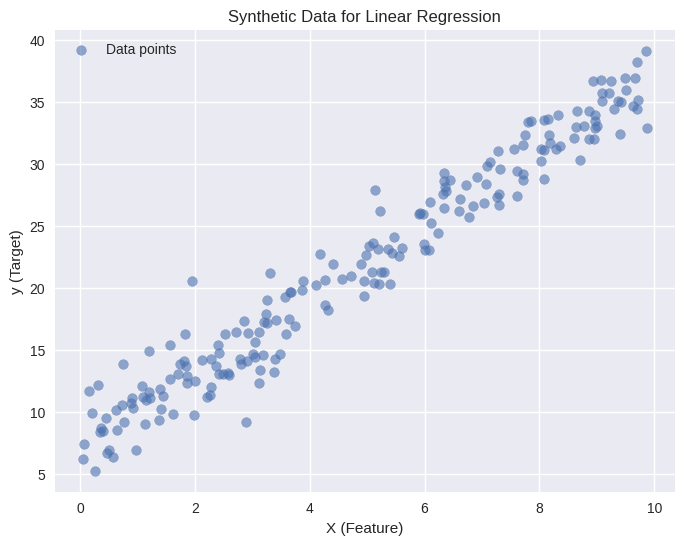

Epoch 0: Loss = 354.8816
Epoch 200: Loss = 5.2791
Epoch 400: Loss = 3.9215
Epoch 600: Loss = 3.7578
Epoch 800: Loss = 3.7380
GD solution - Slope: 2.9897, Intercept: 7.1756


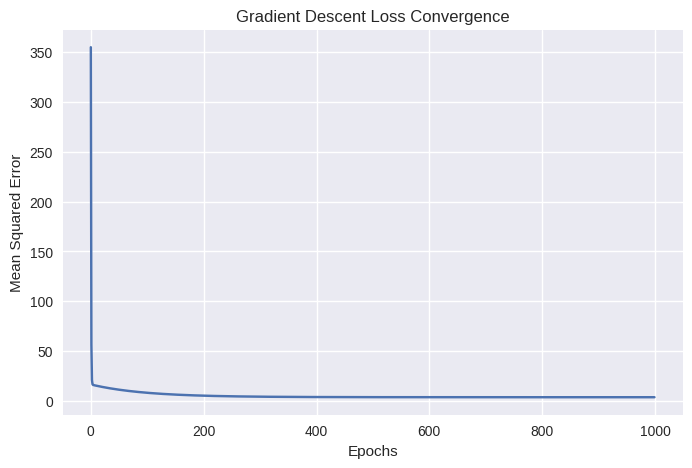

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:

# Linear Regression from Scratch + Scikit-learn

# A simple, educational implementation of Linear Regression using NumPy (manual gradient descent + closed-form solution) and comparison with scikit-learn.

# 1 IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

plt.style.use('seaborn-v0_8')
np.random.seed(42)

# 2. GENERATE SYNTHETIC DATA



X = np.random.rand(200, 1) * 10  # Feature: one column, values between 0-10
noise = np.random.randn(200, 1) * 2
y = 3 * X + 7 + noise  # True relationship: y = 3x + 7 + noise

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6, label='Data points')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data for Linear Regression')
plt.legend()
plt.show()

# 3. LINEAR REGRESSION WITH GRADIENT DESCENT
class LinearRegressionGD:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.slope = None
        self.intercept = None
        self.history = []  # Track loss

    def fit(self, X, y):
        X = X.reshape(-1, 1)
        y = y.reshape(-1, 1)
        m = len(X)

        self.slope = np.random.randn(1)
        self.intercept = np.random.randn(1)

        for epoch in range(self.epochs):
            # Predictions
            y_pred = self.slope * X + self.intercept

            # Compute gradients
            d_slope = (-2/m) * np.sum(X * (y - y_pred))
            d_intercept = (-2/m) * np.sum(y - y_pred)

            # Update parameters
            self.slope -= self.lr * d_slope
            self.intercept -= self.lr * d_intercept

            # Track MSE loss
            loss = np.mean((y - y_pred)**2)
            self.history.append(loss)

            if epoch % 200 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        return self.slope * X + self.intercept

# Train with Gradient Descent
model_gd = LinearRegressionGD(lr=0.01, epochs=1000)
model_gd.fit(X, y.ravel())

print(f"GD solution - Slope: {model_gd.slope[0]:.4f}, Intercept: {model_gd.intercept[0]:.4f}")

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(model_gd.history)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Loss Convergence')
plt.show()

# 4. SCIKIT-LEARN VERSION
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scikit-learn model
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

y_pred_sk = model_sk.predict(X_test)

print(f"scikit-learn - Slope: {model_sk.coef_[0][0]:.4f}, Intercept: {model_sk.intercept_[0]:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_sk):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_sk):.4f}")

# 5. VISUALISATIONS

# Plot all regression lines
plt.figure(figsize=(10, 7))
plt.scatter(X, y, alpha=0.6, label='Data points')

# Closed-form
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(x_line, model_scratch.predict(x_line), 'r-', linewidth=2, label='Closed-form')

# Gradient Descent
plt.plot(x_line, model_gd.predict(x_line), 'g--', linewidth=2, label='Gradient Descent')

# scikit-learn
plt.plot(x_line, model_sk.predict(x_line), 'b-.', linewidth=2, label='scikit-learn')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fits Comparison')
plt.legend()
plt.show()

# 6. MULTIPLE LINEAR REGRESSION

# Generate multiple features
X_multi = np.random.rand(200, 2) * 10
y_multi = 3*X_multi[:,0] + 2*X_multi[:,1] + 5 + np.random.randn(200)*3

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("Multiple LR Coefficients:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)